# Step 1 Data Background

Dataset ini menyajikan catatan historis terkait pasar alpukat di negara Amerika Serikat, yang sumber data berasal dari Hass Avocado Board. Data ini mencakup pengamatan mingguan dari tahun 2015 hingga awal 2018, yang mendokumentasikan fluktuasi harga rata-rata per unit serta volume penjualan total. Informasi yang tersedia tidak hanya terbatas pada angka penjualan kasar, tetapi juga dirinci berdasarkan kode Price Look-Up (PLU) untuk membedakan ukuran alpukat (Small, Large, dan Extra Large), serta kategori kemasan berupa kantong (bags). Dengan cakupan geografis yang luas, dataset ini memetakan tren di 54 wilayah berbeda.

# Step 2 Import Library & Read Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"E:\Aplikasi\db_learn\python\avocado.csv")

# Step 3 Analysing Data & Data Validation

In [18]:
print(f"Total Row : {df.shape[0]}")
print(f"Total Column : {df.shape[1]}\n")
df.info()

Total Row : 18249
Total Column : 14

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18249 entries, 0 to 18248
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    18249 non-null  int64  
 1   Date          18249 non-null  object 
 2   AveragePrice  18249 non-null  float64
 3   Total Volume  18249 non-null  float64
 4   4046          18249 non-null  float64
 5   4225          18249 non-null  float64
 6   4770          18249 non-null  float64
 7   Total Bags    18249 non-null  float64
 8   Small Bags    18249 non-null  float64
 9   Large Bags    18249 non-null  float64
 10  XLarge Bags   18249 non-null  float64
 11  type          18249 non-null  object 
 12  year          18249 non-null  int64  
 13  region        18249 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 1.9+ MB


In [19]:
df.describe()

,Unnamed: 0,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,year
count,18249.000000,18249.000000,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,1.824900e+04,18249.000000,18249.000000
mean,24.232232,1.405978,8.506440e+05,2.930084e+05,2.951546e+05,2.283974e+04,2.396392e+05,1.821947e+05,5.433809e+04,3106.426507,2016.147899
std,15.481045,0.402677,3.453545e+06,1.264989e+06,1.204120e+06,1.074641e+05,9.862424e+05,7.461785e+05,2.439660e+05,17692.894652,0.939938
min,0.000000,0.440000,8.456000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,2015.000000
25%,10.000000,1.100000,1.083858e+04,8.540700e+02,3.008780e+03,0.000000e+00,5.088640e+03,2.849420e+03,1.274700e+02,0.000000,2015.000000
50%,24.000000,1.370000,1.073768e+05,8.645300e+03,2.906102e+04,1.849900e+02,3.974383e+04,2.636282e+04,2.647710e+03,0.000000,2016.000000
75%,38.000000,1.660000,4.329623e+05,1.110202e+05,1.502069e+05,6.243420e+03,1.107834e+05,8.333767e+04,2.202925e+04,132.500000,2017.000000
max,52.000000,3.250000,6.250565e+07,2.274362e+07,2.047057e+07,2.546439e+06,1.937313e+07,1.338459e+07,5.719097e+06,551693.650000,2018.000000


In [20]:
df.dtypes

Unnamed: 0        int64
Date             object
AveragePrice    float64
Total Volume    float64
4046            float64
4225            float64
4770            float64
Total Bags      float64
Small Bags      float64
Large Bags      float64
XLarge Bags     float64
type             object
year              int64
region           object
dtype: object

In [21]:
missing_values = df.isnull().sum()
print('Total Missing Value :')
print(missing_values)

Total Missing Value :
Unnamed: 0      0
Date            0
AveragePrice    0
Total Volume    0
4046            0
4225            0
4770            0
Total Bags      0
Small Bags      0
Large Bags      0
XLarge Bags     0
type            0
year            0
region          0
dtype: int64


In [22]:
duplicate = df.duplicated().sum
print(f"\nTotal Duplicate Data:{duplicate} ")
print(duplicate)


Total Duplicate Data:<bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
18244    False
18245    False
18246    False
18247    False
18248    False
Length: 18249, dtype: bool> 
<bound method Series.sum of 0        False
1        False
2        False
3        False
4        False
         ...  
18244    False
18245    False
18246    False
18247    False
18248    False
Length: 18249, dtype: bool>


In [23]:
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [24]:
for col in df.columns:
    print(f"Kolom '{col}': {df[col].nunique()} nilai unik")

Kolom 'Unnamed: 0': 53 nilai unik
Kolom 'Date': 169 nilai unik
Kolom 'AveragePrice': 259 nilai unik
Kolom 'Total Volume': 18237 nilai unik
Kolom '4046': 17702 nilai unik
Kolom '4225': 18103 nilai unik
Kolom '4770': 12071 nilai unik
Kolom 'Total Bags': 18097 nilai unik
Kolom 'Small Bags': 17321 nilai unik
Kolom 'Large Bags': 15082 nilai unik
Kolom 'XLarge Bags': 5588 nilai unik
Kolom 'type': 2 nilai unik
Kolom 'year': 4 nilai unik
Kolom 'region': 54 nilai unik


# Step 4 Data Cleansing

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
print(df['region'].unique())

['Albany' 'Atlanta' 'BaltimoreWashington' 'Boise' 'Boston'
 'BuffaloRochester' 'California' 'Charlotte' 'Chicago' 'CincinnatiDayton'
 'Columbus' 'DallasFtWorth' 'Denver' 'Detroit' 'GrandRapids' 'GreatLakes'
 'HarrisburgScranton' 'HartfordSpringfield' 'Houston' 'Indianapolis'
 'Jacksonville' 'LasVegas' 'LosAngeles' 'Louisville' 'MiamiFtLauderdale'
 'Midsouth' 'Nashville' 'NewOrleansMobile' 'NewYork' 'Northeast'
 'NorthernNewEngland' 'Orlando' 'Philadelphia' 'PhoenixTucson'
 'Pittsburgh' 'Plains' 'Portland' 'RaleighGreensboro' 'RichmondNorfolk'
 'Roanoke' 'Sacramento' 'SanDiego' 'SanFrancisco' 'Seattle'
 'SouthCarolina' 'SouthCentral' 'Southeast' 'Spokane' 'StLouis' 'Syracuse'
 'Tampa' 'TotalUS' 'West' 'WestTexNewMexico']


In [9]:
df_clean = df[df['region'] != 'TotalUS']
# Cek jumlah baris yang tersisa
print(f"Jumlah data sebelum filter: {len(df)}")
print(f"Jumlah data setelah filter: {len(df_clean)}")

Jumlah data sebelum filter: 18249
Jumlah data setelah filter: 17911


In [10]:
print(df_clean['region'].unique())

['Albany' 'Atlanta' 'BaltimoreWashington' 'Boise' 'Boston'
 'BuffaloRochester' 'California' 'Charlotte' 'Chicago' 'CincinnatiDayton'
 'Columbus' 'DallasFtWorth' 'Denver' 'Detroit' 'GrandRapids' 'GreatLakes'
 'HarrisburgScranton' 'HartfordSpringfield' 'Houston' 'Indianapolis'
 'Jacksonville' 'LasVegas' 'LosAngeles' 'Louisville' 'MiamiFtLauderdale'
 'Midsouth' 'Nashville' 'NewOrleansMobile' 'NewYork' 'Northeast'
 'NorthernNewEngland' 'Orlando' 'Philadelphia' 'PhoenixTucson'
 'Pittsburgh' 'Plains' 'Portland' 'RaleighGreensboro' 'RichmondNorfolk'
 'Roanoke' 'Sacramento' 'SanDiego' 'SanFrancisco' 'Seattle'
 'SouthCarolina' 'SouthCentral' 'Southeast' 'Spokane' 'StLouis' 'Syracuse'
 'Tampa' 'West' 'WestTexNewMexico']


# Step 5 Data Visualisation

## Tren Harga VS Volume
### Kasus 1
Perhatikan puncak tertinggi garis merah. Di sana harga melonjak drastis hingga hampir 1.85. Lihat garis birunya di bulan yang sama: Garis biru terjun bebas ke titik terendahnya (sekitar 1.75). 
Insight : "pada September 2017, kenaikan harga yang sangat tinggi berkorelasi kuat dengan penurunan drastis volume penjualan".

### Kasus 2
Harga merah turun ke titik rendah (sekitar 1.2). Lihat garis birunya: Garis biru melonjak naik (puncak kedua tertinggi).
Insight: "Saat harga murah, orang membeli alpukat dalam jumlah yang jauh lebih banyak."

### Kesimpulan
Kesimpulan Analisis untuk Laporan Kamu
Secara keseluruhan, dataset Avocado ini menunjukkan Korelasi Negatif yang sangat jelas.

Analisis: Grafik menunjukkan pola "berlawanan arah" (seperti cermin). Hampir di setiap titik di mana garis merah (Price) naik, garis biru (Volume) akan turun. Ini membuktikan bahwa permintaan pasar alpukat sangat sensitif terhadap harga (Price Elasticity). Penjualan paling drastis terjadi saat harga mencapai puncaknya di akhir tahun 2017.

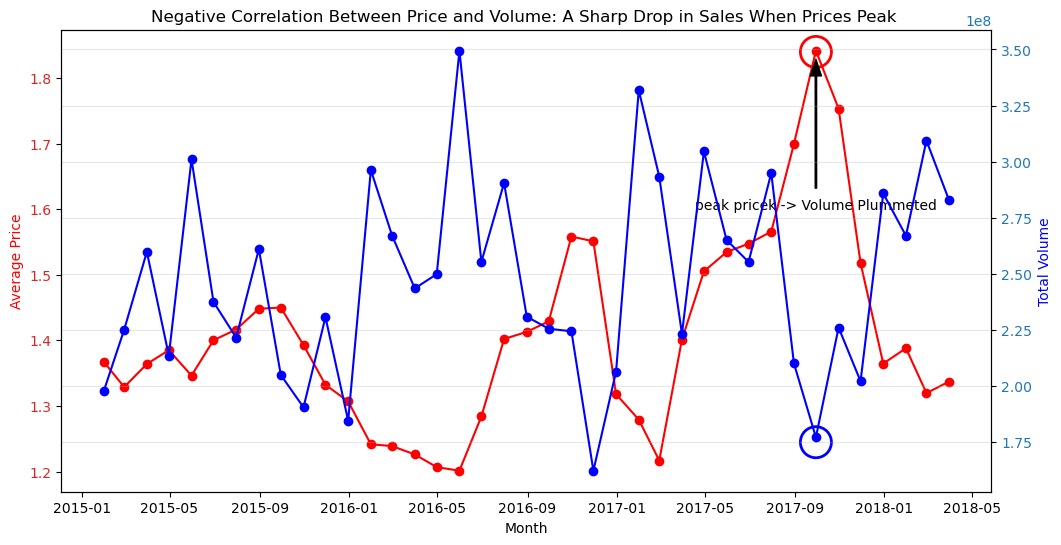

In [11]:

df_month = df_clean.set_index('Date').resample('ME').agg({
    'AveragePrice': 'mean',
    'Total Volume': 'sum'
})

# 
fig, ax1 = plt.subplots(figsize=(12, 6))

# Garis Pertama: Average Price (Sumbu Y Kiri)
color = 'tab:red'
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Price', color=color)
ax1.plot(df_month.index, df_month['AveragePrice'], color='red', marker='o', label='Price')
ax1.set_ylabel('Average Price', color='red')
ax1.tick_params(axis='y', labelcolor=color)

# Membuat Sumbu Y Kedua (Sumbu Y Kanan)
ax2 = ax1.twinx()
color= 'tab:blue'
ax2.set_ylabel('Total Volume', color=color)
ax2.plot(df_month.index, df_month['Total Volume'], color='blue', marker='o', label='Volume')
ax2.set_ylabel('Total Volume', color='blue')
ax2.tick_params(axis='y', labelcolor=color)

# 1. Menentukan Koordinat Titik Penting (Sept 2017)
# Ganti dengan koordinat yang tepat dari dataset bulanan kamu
x_target =pd.to_datetime('2017-09-30')
y_price = 1.84
y_volume = 175000000

# Lingkaran Harga (Merah)
ax1.scatter(x_target, y_price, s=500, facecolors='none', edgecolors='red', linewidths=2, label='Annotation Price')
# Lingkaran Volume (Biru) - Perhatikan penggunaan ax2
ax2.scatter(x_target, y_volume, s=500, facecolors='none', edgecolors='blue', linewidths=2)

ax1.annotate('peak pricek -> Volume Plummeted',
    xy=(x_target, y_price),
    xytext=(x_target, 1.6),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
    horizontalalignment='center')
    

plt.title('Negative Correlation Between Price and Volume: A Sharp Drop in Sales When Prices Peak ')
plt.grid(True, alpha=0.3)
plt.show()

In [12]:
df.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [13]:
idxmax_price = df_month['AveragePrice'].idxmax()

y_price = df_month.loc[idxmax_price, 'AveragePrice']
y_volume = df_month.loc[idxmax_price, 'Total Volume']

x_target = idxmax_price
print(x_target)

2017-09-30 00:00:00


## Distribusi Harga Per Tipe
Analisis Tren menunjukkan bahwa volume penjualan Avocado sangat sensitif terhadap kenaikan harga. Analisis Distribusi (Boxplot) ini memperjelas bahwa sensitivitas tersebut kemungkinan besar paling banyak disumbang oleh tipe Konvensional, karena harga mediannya jauh lebih rendah dan rentang harganya lebih stabil. Konsumen tipe Konvensional lebih terbiasa dengan harga murah dan akan langsung bereaksi jika harga naik sedikit saja.

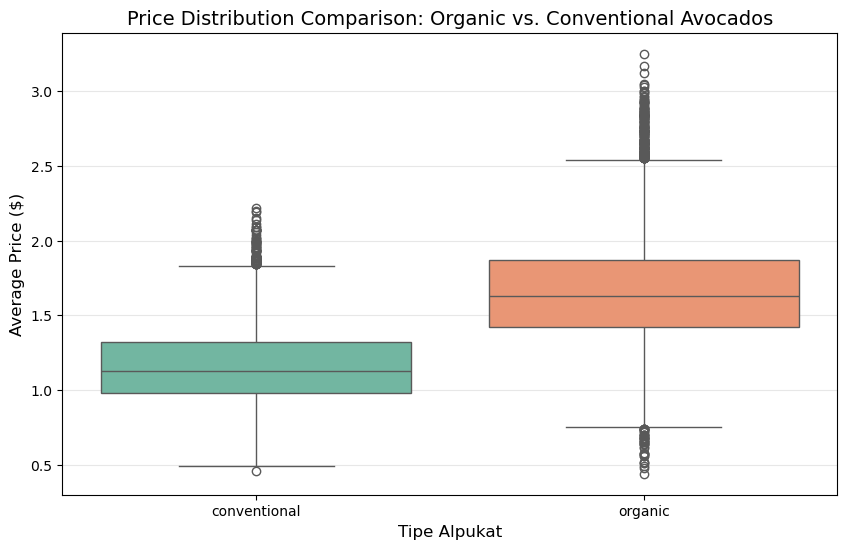

In [14]:
# Distributin Price Type
plt.figure(figsize=(10,6))
sns.boxplot(x='type', y='AveragePrice', data=df_clean, palette='Set2', hue='type', legend=False)

plt.title('Price Distribution Comparison: Organic vs. Conventional Avocados', fontsize=14)
plt.xlabel('Tipe Alpukat', fontsize=12)
plt.ylabel('Average Price ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Correlation Analysis: Determinants of Total Sales
### Key Findings
The purpose of the correlation analysis is to measure the strength of the relationship between price, total volume, and the size of each Avocado (Small, Large, XLarge)
1. **Size Dominance:** "Avocados in Small (4046) and Large (4225) sizes show a very strong correlation with Total Volume (with values of 0.9 and 0.87); these figures indicate that both avocado sizes are **the main drivers of sales volume**".
2. **The Relationship Between Price and Volume:** "A negative correlation was found between the average price and total volume (-0.34). Mathematically, this indicates that an increase in price tends to be followed by a decrease in the demand for avocados".
3. **Correlation Between Sizes:** "The Small and Large sizes show a moderate correlation (0.60), this indicates that the sizes of these two products often follow **the same demand trends in the market**".
### Business Impact
#### Strategic Recommendations
1. **Stock Priorities:** By reviewing the very high correlation between Measure 4046 and Total Volume, prioritise stock availability for### Temuan Utama
Analisis Korelasi memiliki tujuan mengukur kekuatan hungan pada harga, total volume, dan ukuran setiap dari Avocado(Small ,Large, XLarge)
1. **Dominasi Ukuran:** "Avocado dengan ukuran Small(4046) dan Large(4225) mempunyai korelasi yang sangat Kuat terhadap Total Volume dengan (Nilai 0.9 dan 0.87) nilai tersebut bahwa kedua ukuran Avocado menjadi **pendorong utama volume penjualan**".
2. **Keterkaitan Antara Harga VS Volume:** "Ditemukan Korelasi Negatif antara Average Price dan Total Volume(-0.34). Secara matematis, hal ini menunjukkan bahwa kenaikan harga cenderung diikuti dengan penurungan jumlah permintaan Avocado".
3. **Korelasi Antar Ukuran:** "untuk ukuran Small dan Large mempunyai Korelasi Moderat(0.60), isyarat ini bahwa ukuran kedua produk tersebut sering kali terjadi **tren permintaan yang sama di pasar**".
### Dampak Bisnis 
#### Rekomendasi Strategis
1. **Prioritas Stok:** Dengan meninjau kembali Korelasi Ukuran 4046 yang sangat Tinggi terhadap Total Volume, memprioritaskan ketersediaan stok  ukuran ini untuk menjaga kestabilan revenue
2. **Sensitivitas Harga:** Bgaian harga memiliki harga bersifat korealsi Negatif, perlu diperhatikan ketika menaikkan harga pada ukuran Small dan Large, karena ini berkaitan langsung pada penurunan volume secara signifikan.

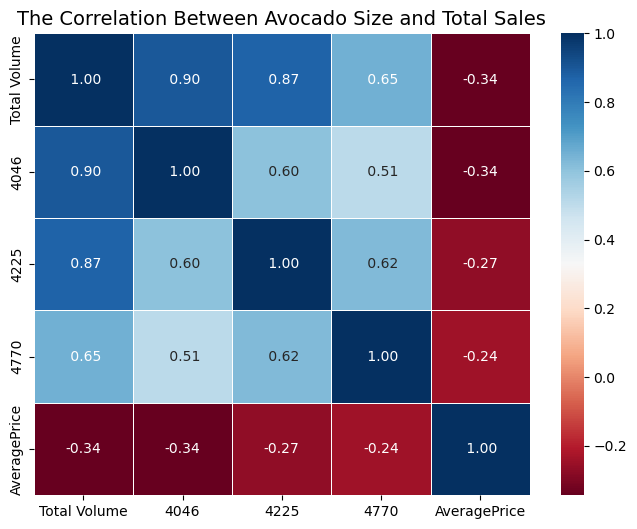

In [15]:
# Select the columns for which you want to view the correlation
cols = ['Total Volume', '4046', '4225', '4770', 'AveragePrice']
corr_matrix = df_clean[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu', fmt=' .2f', linewidth=0.5)

plt.title('The Correlation Between Avocado Size and Total Sales', fontsize=14)
plt.show()